# VoltRelay Energy — Network Performance Analysis
## Setup & Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 150)
sns.set_style('whitegrid')

DATA_DIR = '../data/raw' 

##  Load Data

In [4]:
swap_events = pd.read_csv(os.path.join(DATA_DIR, 'swap_events.csv'))
station_hourly = pd.read_csv(os.path.join(DATA_DIR, 'station_hourly_status.csv'))
riders = pd.read_csv(os.path.join(DATA_DIR, 'riders.csv'))
batteries = pd.read_csv(os.path.join(DATA_DIR, 'batteries.csv'))
support_tickets = pd.read_csv(os.path.join(DATA_DIR, 'support_tickets.csv'))
stations = pd.read_csv(os.path.join(DATA_DIR, 'stations.csv'))
city_daily = pd.read_csv(os.path.join(DATA_DIR, 'city_daily_context.csv'))
fleet_partners = pd.read_csv(os.path.join(DATA_DIR, 'fleet_partners.csv'))

dfs = {
    'swap_events': swap_events,
    'station_hourly': station_hourly,
    'riders': riders,
    'batteries': batteries,
    'support_tickets': support_tickets,
    'stations': stations,
    'city_daily': city_daily,
    'fleet_partners': fleet_partners
}

In [5]:
expected_rows = {
    'swap_events': 3_877_013,
    'station_hourly': 1_487_712,
    'riders': 20_000,
    'batteries': 6_500,
    'support_tickets': 44_000,
    'stations': 152,
    'city_daily': 3_282,
    'fleet_partners': 12
}

print(f"{'File':<18} {'Actual':>10} {'Expected':>10} {'Match':>7}")
for name, df in dfs.items():
    actual = len(df)
    expected = expected_rows[name]
    print(f"{name:<18} {actual:>10,} {expected:>10,} {'OK' if actual == expected else 'MISMATCH':>7}")

File                   Actual   Expected   Match
swap_events         3,877,013  3,877,013      OK
station_hourly      1,487,712  1,487,712      OK
riders                 20,000     20,000      OK
batteries               6,500      6,500      OK
support_tickets        44,000     44,000      OK
stations                  152        152      OK
city_daily              3,282      3,282      OK
fleet_partners             12         12      OK


##  Data Understanding 

In [7]:
for name, df in dfs.items():
    print(f"\n{'='*60}\n{name.upper()}  —  shape: {df.shape}\n{'='*60}")
    print(df.dtypes)
    print("\nMissing values (%):")
    print((df.isnull().mean() * 100).round(2).sort_values(ascending=False).head(10))


SWAP_EVENTS  —  shape: (3877013, 22)
event_id                   object
rider_id                   object
station_id                 object
event_ts                   object
event_type                 object
attempt_seq                 int64
queue_wait_sec              int64
battery_in_id              object
battery_out_id             object
soc_in_pct                float64
soh_in_pct                float64
soc_out_pct               float64
soh_out_pct               float64
km_since_last_swap        float64
tariff_code                object
list_price_inr            float64
discount_inr              float64
amount_charged_inr        float64
payment_mode               object
energy_to_recharge_kwh    float64
station_firmware           object
sync_mode                  object
dtype: object

Missing values (%):
soc_out_pct               5.96
battery_out_id            5.96
energy_to_recharge_kwh    5.96
soh_out_pct               5.96
soc_in_pct                0.73
soh_in_pct              

In [8]:
for name, df in dfs.items():
    print(f"\n--- {name} ---")
    display(df.head(3))


--- swap_events ---


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,soh_in_pct,soc_out_pct,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,100.6,98.7,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,98.3,97.3,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,99.1,99.8,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime



--- station_hourly ---


,station_id,hour_start,charged_2w_avg,charged_2w_min,charged_3w_min,packs_charging,packs_quarantined,chargers_online,ambient_temp_c,cabinet_temp_c,avg_charge_minutes,outage_minutes,grid_kwh,telemetry_status
0,STN-BLR-001,2024-01-01 00:00:00,6.29,6.0,4.0,1.0,0.0,18,8.2,13.5,92.6,0,1.86,ok
1,STN-BLR-001,2024-01-01 01:00:00,8.10,8.0,4.0,8.0,0.0,18,8.2,11.5,88.0,0,13.96,ok
2,STN-BLR-001,2024-01-01 02:00:00,10.56,8.0,4.0,5.0,0.0,18,8.2,12.9,80.2,0,8.27,ok



--- riders ---


...

,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,charger_generation,slots_2w,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,Gen1,12,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,Gen2,16,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,Gen2,16,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN



--- city_daily ---


,city,date,max_temp_c,min_temp_c,rainfall_mm,heat_alert,flood_disruption,festival_or_event,is_public_holiday,grid_outage_hours,competitor_promo_active,ecommerce_sale_event
0,Bengaluru,2024-01-01,16.7,6.7,0.0,False,False,NaN,False,0.0,False,False
1,Bengaluru,2024-01-02,17.3,4.6,1.8,False,False,NaN,False,0.2,False,False
2,Bengaluru,2024-01-03,13.9,6.9,0.7,False,False,NaN,False,0.0,False,False



--- fleet_partners ---


,partner_id,partner_name,partner_segment,vehicle_class,contract_type,contract_start_date,discount_pct,amendment_date,discount_pct_after_amendment,peak_surcharge_billable,payment_terms_days,cities_active
0,FP-01,FeastFly,food_delivery,2W,volume_tiered,2023-04-01,10.0,NaN,NaN,Y,30,BLR|DEL|HYD|PUN|MUM|JAI
1,FP-02,ParcelNest,ecom_logistics,2W,pay_per_swap,2023-07-01,15.0,NaN,NaN,Y,30,BLR|DEL|HYD|MUM
2,FP-03,ZipDrop,quick_commerce,2W,volume_tiered,2023-06-01,12.0,2024-11-01,28.0,N,45,BLR|DEL|HYD|PUN|MUM|JAI


## Target Data Quality Checks

In [10]:
print(swap_events['event_type'].value_counts())
print()
print(swap_events['event_type'].value_counts(normalize=True).round(4) * 100)

event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64

event_type
swap_completed               94.04
failed_no_charged_battery     3.47
abandoned_queue               1.77
cancelled_by_rider            0.43
failed_system_error           0.30
Name: proportion, dtype: float64


In [11]:
print(f"Unique home_city values: {riders['home_city'].nunique()}")
print(riders['home_city'].value_counts())

Unique home_city values: 21
home_city
Bengaluru     4175
Delhi NCR     3783
Hyderabad     3396
Pune          2843
Mumbai        2772
Jaipur        2446
Bombay          53
BLR             53
bengaluru       50
MUM             49
pune            43
PUN             43
New Delhi       42
JAI             41
Gurgaon         36
Bangalore       32
HYD             31
Hyd             31
jaipur          29
hyderabad       27
Delhi           25
Name: count, dtype: int64


In [12]:
print(station_hourly['telemetry_status'].value_counts())
print()
print(station_hourly['telemetry_status'].value_counts(normalize=True).round(4) * 100)

telemetry_status
ok         1441341
partial      36987
missing       9384
Name: count, dtype: int64

telemetry_status
ok         96.88
partial     2.49
missing     0.63
Name: proportion, dtype: float64


In [13]:
print(swap_events['station_firmware'].value_counts())

station_firmware
v3.2.1    2315839
v3.2.0    1561174
Name: count, dtype: int64


In [14]:
print(swap_events['sync_mode'].value_counts())

sync_mode
realtime         3285899
offline_batch     591114
Name: count, dtype: int64


In [15]:
print(f"csat_score missing: {support_tickets['csat_score'].isnull().mean()*100:.1f}%")
print()
print(support_tickets.groupby('resolution_status')['csat_score'].apply(lambda x: x.notnull().mean()*100).round(1))

csat_score missing: 65.6%

resolution_status
duplicate      0.0
resolved      39.9
unresolved     0.0
Name: csat_score, dtype: float64


In [16]:
test_stations = stations[stations['station_id'].str.startswith('STN-TST')]
print(f"Test stations found: {len(test_stations)}")
print(test_stations[['station_id', 'city', 'commissioned_date']])

Test stations found: 2
     station_id       city commissioned_date
150  STN-TST-01  Bengaluru        2023-06-01
151  STN-TST-02  Bengaluru        2023-06-01


##  Data Cleaning

In [18]:
swap_events['event_ts'] = pd.to_datetime(swap_events['event_ts'])

bug_mask = (
    (swap_events['station_firmware'] == 'v3.2.0') &
    (swap_events['event_ts'] >= '2025-03-10') &
    (swap_events['event_ts'] <= '2025-04-14 23:59:59')
)

print(f"Rows affected by timezone bug: {bug_mask.sum():,}")

swap_events.loc[bug_mask, 'event_ts'] = swap_events.loc[bug_mask, 'event_ts'] + pd.Timedelta(hours=5, minutes=30)

print("Timestamp fix applied.")

Rows affected by timezone bug: 139,490
Timestamp fix applied.


In [19]:
city_map = {
    'Bengaluru': 'Bengaluru', 'BLR': 'Bengaluru', 'bengaluru': 'Bengaluru', 'Bangalore': 'Bengaluru',
    'Delhi NCR': 'Delhi NCR', 'New Delhi': 'Delhi NCR', 'Gurgaon': 'Delhi NCR', 'Delhi': 'Delhi NCR',
    'Mumbai': 'Mumbai', 'Bombay': 'Mumbai', 'MUM': 'Mumbai',
    'Pune': 'Pune', 'pune': 'Pune', 'PUN': 'Pune',
    'Jaipur': 'Jaipur', 'JAI': 'Jaipur', 'jaipur': 'Jaipur',
    'Hyderabad': 'Hyderabad', 'HYD': 'Hyderabad', 'Hyd': 'Hyderabad', 'hyderabad': 'Hyderabad',
}

riders['home_city_clean'] = riders['home_city'].map(city_map)

# Verify no unmapped values slipped through
unmapped = riders[riders['home_city_clean'].isnull()]
print(f"Unmapped rows: {len(unmapped)}")
print(riders['home_city_clean'].value_counts())

Unmapped rows: 50
home_city_clean
Bengaluru    4260
Delhi NCR    3886
Hyderabad    3485
Pune         2929
Mumbai       2874
Jaipur       2516
Name: count, dtype: int64


In [20]:
unmapped_values = riders[riders['home_city_clean'].isnull()]['home_city'].value_counts()
print(unmapped_values)

home_city
bengaluru     50
Name: count, dtype: int64


In [21]:
# Check for whitespace or invisible characters
sample = riders[riders['home_city'] == 'bengaluru']['home_city']
print(sample.apply(lambda x: repr(x)).head())
print()
print(f"Length of a normal 'Bengaluru' string: {len('Bengaluru')}")
print(f"Length of these values: {sample.str.len().unique()}")

Series([], Name: home_city, dtype: object)

Length of a normal 'Bengaluru' string: 9
Length of these values: []


In [22]:
# Normalize: strip whitespace and lowercase before mapping
riders['home_city_norm'] = riders['home_city'].str.strip().str.lower()

city_map_norm = {
    'bengaluru': 'Bengaluru', 'blr': 'Bengaluru', 'bangalore': 'Bengaluru',
    'delhi ncr': 'Delhi NCR', 'new delhi': 'Delhi NCR', 'gurgaon': 'Delhi NCR', 'delhi': 'Delhi NCR',
    'mumbai': 'Mumbai', 'bombay': 'Mumbai', 'mum': 'Mumbai',
    'pune': 'Pune', 'pun': 'Pune',
    'jaipur': 'Jaipur', 'jai': 'Jaipur',
    'hyderabad': 'Hyderabad', 'hyd': 'Hyderabad',
}

riders['home_city_clean'] = riders['home_city_norm'].map(city_map_norm)

unmapped = riders[riders['home_city_clean'].isnull()]
print(f"Unmapped rows: {len(unmapped)}")
print(riders['home_city_clean'].value_counts())

riders = riders.drop(columns=['home_city_norm'])

Unmapped rows: 0
home_city_clean
Bengaluru    4310
Delhi NCR    3886
Hyderabad    3485
Pune         2929
Mumbai       2874
Jaipur       2516
Name: count, dtype: int64


In [23]:
stations['is_test_station'] = stations['station_id'].str.startswith('STN-TST')
print(f"Test stations flagged: {stations['is_test_station'].sum()}")

# Create a clean version excluding test stations for network-performance analysis
stations_clean = stations[~stations['is_test_station']].copy()
print(f"stations_clean shape: {stations_clean.shape}")

Test stations flagged: 2
stations_clean shape: (150, 23)


In [24]:
swap_events_sorted = swap_events.sort_values(['rider_id', 'station_id', 'event_ts']).copy()

swap_events_sorted['prev_ts'] = swap_events_sorted.groupby(['rider_id', 'station_id'])['event_ts'].shift(1)
swap_events_sorted['time_diff_sec'] = (swap_events_sorted['event_ts'] - swap_events_sorted['prev_ts']).dt.total_seconds()

# Near-duplicate: same rider+station, within 2 minutes, and marked offline_batch
dup_mask = (
    (swap_events_sorted['time_diff_sec'] <= 120) &
    (swap_events_sorted['time_diff_sec'] >= 0) &
    (swap_events_sorted['sync_mode'] == 'offline_batch')
)

print(f"Likely near-duplicate events: {dup_mask.sum():,}")

swap_events_sorted['is_likely_duplicate'] = dup_mask
swap_events = swap_events_sorted.drop(columns=['prev_ts', 'time_diff_sec'])

Likely near-duplicate events: 652


In [25]:
print(swap_events['km_since_last_swap'].describe())
print()
negative_count = (swap_events['km_since_last_swap'] < 0).sum()
extreme_count = (swap_events['km_since_last_swap'] > 500).sum()  # tune threshold after seeing describe() output
print(f"Negative values: {negative_count:,}")
print(f"Values > 500 km: {extreme_count:,}")

count    3.848731e+06
mean     6.203515e+01
std      2.044107e+01
min     -2.000000e+01
25%      5.190000e+01
50%      6.000000e+01
75%      6.900000e+01
max      4.200000e+02
Name: km_since_last_swap, dtype: float64

Negative values: 7,814
Values > 500 km: 0


In [26]:
print(f"Before: {swap_events['km_since_last_swap'].isnull().sum():,} missing")

swap_events.loc[swap_events['km_since_last_swap'] < 0, 'km_since_last_swap'] = np.nan

print(f"After: {swap_events['km_since_last_swap'].isnull().sum():,} missing")
print(swap_events['km_since_last_swap'].describe())

Before: 28,282 missing
After: 36,096 missing
count    3.840917e+06
mean     6.218271e+01
std      2.019654e+01
min      2.210000e+01
25%      5.190000e+01
50%      6.000000e+01
75%      6.900000e+01
max      4.200000e+02
Name: km_since_last_swap, dtype: float64


In [27]:
pct_cols = ['soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct']
for col in pct_cols:
    above_100 = (swap_events[col] > 100).sum()
    print(f"{col}: {above_100:,} values above 100%")

# Cap at 100 (sensor drift correction)
for col in pct_cols:
    swap_events[col] = swap_events[col].clip(upper=100)

soc_in_pct: 0 values above 100%
soh_in_pct: 3,356 values above 100%
soc_out_pct: 3,698 values above 100%
soh_out_pct: 2,799 values above 100%


##  Feature Engineering

In [29]:
swap_events['is_completed'] = (swap_events['event_type'] == 'swap_completed').astype(int)
swap_events['event_date'] = swap_events['event_ts'].dt.date
swap_events['hour_of_day'] = swap_events['event_ts'].dt.hour
swap_events['event_month'] = swap_events['event_ts'].dt.to_period('M')

# Simple season bucket (India: winter/summer/monsoon) — tune boundaries if needed
def get_season(month):
    if month in [12, 1, 2]:
        return 'winter'
    elif month in [3, 4, 5, 6]:
        return 'summer'
    else:
        return 'monsoon'

swap_events['season'] = swap_events['event_ts'].dt.month.apply(get_season)

print(swap_events[['event_ts', 'is_completed', 'hour_of_day', 'season']].head())
print()
print(swap_events['season'].value_counts())

                  event_ts  is_completed  hour_of_day  season
58627  2024-01-18 12:53:27             1           12  winter
464156 2024-04-28 13:54:40             1           13  summer
379806 2024-04-09 09:52:25             1            9  summer
55031  2024-01-17 00:35:12             1            0  winter
210284 2024-02-27 11:02:04             1           11  winter

season
summer     1845622
winter     1036270
monsoon     995121
Name: count, dtype: int64


In [30]:
swap_events = swap_events.merge(
    stations[['station_id', 'city', 'zone', 'location_type', 'host_type',
              'expansion_wave', 'charger_generation', 'is_test_station']],
    on='station_id', how='left'
)

print(f"swap_events shape after station merge: {swap_events.shape}")
print(swap_events['city'].value_counts())
print(f"\nMissing city (unmatched station_id): {swap_events['city'].isnull().sum()}")

swap_events shape after station merge: (3877013, 35)
city
Bengaluru    825327
Delhi NCR    768913
Hyderabad    711930
Pune         552910
Mumbai       530299
Jaipur       487634
Name: count, dtype: int64

Missing city (unmatched station_id): 0


In [31]:
swap_events = swap_events.merge(
    riders[['rider_id', 'partner_id', 'vehicle_class', 'home_city_clean',
            'signup_date', 'plan_type', 'signup_channel']],
    on='rider_id', how='left'
)

print(f"swap_events shape after rider merge: {swap_events.shape}")
print(f"Missing rider match: {swap_events['vehicle_class'].isnull().sum()}")

swap_events shape after rider merge: (3877013, 41)
Missing rider match: 0


In [32]:
swap_events['signup_date'] = pd.to_datetime(swap_events['signup_date'])
swap_events['rider_tenure_days'] = (swap_events['event_ts'] - swap_events['signup_date']).dt.days

print(swap_events['rider_tenure_days'].describe())
print(f"\nNegative tenure (swap before signup?): {(swap_events['rider_tenure_days'] < 0).sum()}")

count    3.877013e+06
mean     2.202798e+02
std      1.802004e+02
min      0.000000e+00
25%      7.400000e+01
50%      1.760000e+02
75%      3.240000e+02
max      8.450000e+02
Name: rider_tenure_days, dtype: float64

Negative tenure (swap before signup?): 0


In [33]:
# grid_tariff_inr_kwh comes from stations; merge it in for cost calculation
swap_events = swap_events.merge(
    stations[['station_id', 'grid_tariff_inr_kwh']],
    on='station_id', how='left'
)

swap_events['energy_cost_inr'] = swap_events['energy_to_recharge_kwh'] * swap_events['grid_tariff_inr_kwh']
swap_events['contribution_inr'] = swap_events['amount_charged_inr'] - swap_events['energy_cost_inr']

print(swap_events[['amount_charged_inr', 'energy_cost_inr', 'contribution_inr']].describe())

       amount_charged_inr  energy_cost_inr  contribution_inr
count        3.877013e+06     3.645809e+06      3.645809e+06
mean         6.013033e+01     1.949831e+01      4.444526e+01
std          2.069786e+01     7.787826e+00      1.008520e+01
min          0.000000e+00     6.915000e+00      1.414320e+01
25%          5.520000e+01     1.567266e+01      3.794222e+01
50%          5.850000e+01     1.739259e+01      4.282540e+01
75%          6.500000e+01     1.930775e+01      4.912828e+01
max          1.350000e+02     6.117930e+01      1.045875e+02


## Question 1: Network Performance Over Time

In [35]:
monthly = swap_events.groupby('event_month').agg(
    total_attempts=('event_id', 'count'),
    completed_swaps=('is_completed', 'sum'),
    total_revenue=('amount_charged_inr', 'sum'),
    avg_contribution=('contribution_inr', 'mean'),
    avg_queue_wait=('queue_wait_sec', 'mean')
).reset_index()

monthly['failure_rate_pct'] = (1 - monthly['completed_swaps'] / monthly['total_attempts']) * 100
monthly['event_month'] = monthly['event_month'].astype(str)

print(monthly)

   event_month  total_attempts  completed_swaps  total_revenue  avg_contribution  avg_queue_wait  failure_rate_pct
0      2024-01          110348           105490     6318995.20         37.899554      242.286711          4.402436
1      2024-02          111531           106582     6387614.80         38.030102      243.473169          4.437331
2      2024-03          123900           118444     7093617.00         38.172220      242.204730          4.403551
3      2024-04          131818           122836     7370255.80         38.406142      243.329720          6.813940
4      2024-05          146278           128328     7689594.00         38.585225      242.733945         12.271155
5      2024-06          148888           133743     8003275.60         38.804795      242.320268         10.172076
6      2024-07          158688           151824     9879524.60         44.217085      243.129657          4.325469
7      2024-08          172295           164931    10724296.65         44.375894

C:\Users\User\AppData\Local\Temp\ipykernel_24272\2785389610.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly['event_month'], rotation=45, ha='right')


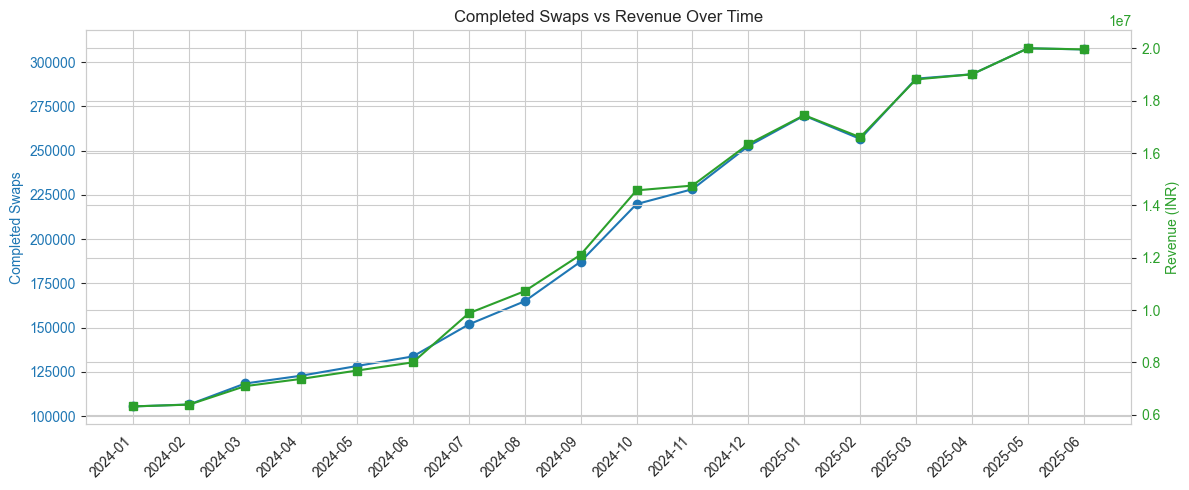

In [36]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly['event_month'], monthly['completed_swaps'], color='tab:blue', marker='o', label='Completed Swaps')
ax1.set_ylabel('Completed Swaps', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')
ax1.set_xticklabels(monthly['event_month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['event_month'], monthly['total_revenue'], color='tab:green', marker='s', label='Revenue (INR)')
ax2.set_ylabel('Revenue (INR)', color='tab:green')
ax2.tick_params(axis='y', labelcolor='tab:green')

plt.title('Completed Swaps vs Revenue Over Time')
fig.tight_layout()
plt.savefig('../outputs/figures/q1_swaps_vs_revenue.png', dpi=150)
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_24272\686302138.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(monthly['event_month'], rotation=45, ha='right')


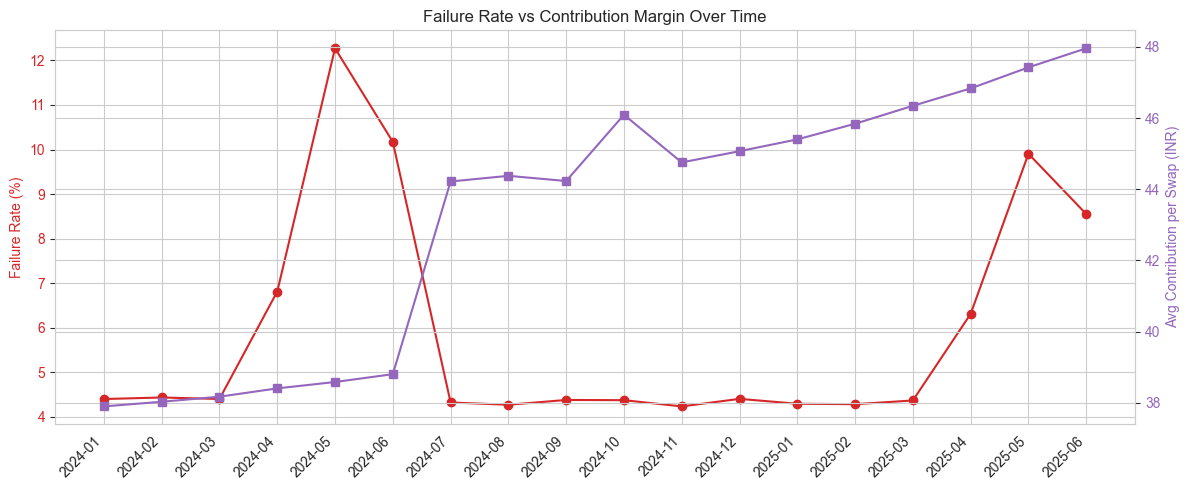

In [37]:
fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(monthly['event_month'], monthly['failure_rate_pct'], color='tab:red', marker='o', label='Failure Rate %')
ax1.set_ylabel('Failure Rate (%)', color='tab:red')
ax1.tick_params(axis='y', labelcolor='tab:red')
ax1.set_xticklabels(monthly['event_month'], rotation=45, ha='right')

ax2 = ax1.twinx()
ax2.plot(monthly['event_month'], monthly['avg_contribution'], color='tab:purple', marker='s', label='Avg Contribution/Swap (INR)')
ax2.set_ylabel('Avg Contribution per Swap (INR)', color='tab:purple')
ax2.tick_params(axis='y', labelcolor='tab:purple')

plt.title('Failure Rate vs Contribution Margin Over Time')
fig.tight_layout()
plt.savefig('../outputs/figures/q1_failure_vs_margin.png', dpi=150)
plt.show()

##  Confirming Hypotheses: Seasonality & Pricing Step-Change

In [39]:
city_daily['date'] = pd.to_datetime(city_daily['date'])
city_daily['month'] = city_daily['date'].dt.to_period('M').astype(str)

monthly_heat = city_daily.groupby('month').agg(
    avg_max_temp=('max_temp_c', 'mean'),
    heat_alert_days=('heat_alert', 'sum')
).reset_index()

print(monthly_heat)

      month  avg_max_temp  heat_alert_days
0   2024-01     14.969355                0
1   2024-02     17.371839                0
2   2024-03     23.872043                0
3   2024-04     33.051667                0
4   2024-05     39.558602               71
5   2024-06     35.576667                2
6   2024-07     24.020968                0
7   2024-08     22.809677                0
8   2024-09     25.346111                0
9   2024-10     22.583333                0
10  2024-11     17.645000                0
11  2024-12     14.891398                0
12  2025-01     14.993548                0
13  2025-02     17.575000                0
14  2025-03     24.136559                0
15  2025-04     33.117222                0
16  2025-05     39.572043               66
17  2025-06     35.753889               11


In [40]:
comparison = monthly.merge(monthly_heat, left_on='event_month', right_on='month')
print(comparison[['event_month', 'failure_rate_pct', 'avg_max_temp', 'heat_alert_days']])

   event_month  failure_rate_pct  avg_max_temp  heat_alert_days
0      2024-01          4.402436     14.969355                0
1      2024-02          4.437331     17.371839                0
2      2024-03          4.403551     23.872043                0
3      2024-04          6.813940     33.051667                0
4      2024-05         12.271155     39.558602               71
5      2024-06         10.172076     35.576667                2
6      2024-07          4.325469     24.020968                0
7      2024-08          4.274065     22.809677                0
8      2024-09          4.381653     25.346111                0
9      2024-10          4.377101     22.583333                0
10     2024-11          4.237011     17.645000                0
11     2024-12          4.406183     14.891398                0
12     2025-01          4.296400     14.993548                0
13     2025-02          4.287222     17.575000                0
14     2025-03          4.370278     24.

In [41]:
monthly_price = swap_events[swap_events['is_completed'] == 1].groupby('event_month').agg(
    avg_list_price=('list_price_inr', 'mean'),
    avg_amount_charged=('amount_charged_inr', 'mean')
).reset_index()
monthly_price['event_month'] = monthly_price['event_month'].astype(str)

print(monthly_price)

   event_month  avg_list_price  avg_amount_charged
0      2024-01       64.476633           59.901367
1      2024-02       64.520838           59.931459
2      2024-03       64.450711           59.890049
3      2024-04       64.529291           60.000780
4      2024-05       64.435509           59.921405
5      2024-06       64.327703           59.840706
6      2024-07       69.936176           65.072219
7      2024-08       69.906506           65.022929
8      2024-09       69.563619           64.682756
9      2024-10       69.478753           66.309153
10     2024-11       69.506052           64.663577
11     2024-12       69.554669           64.696310
12     2025-01       69.528300           64.672614
13     2025-02       69.542743           64.702276
14     2025-03       69.541263           64.724605
15     2025-04       69.624817           64.840931
16     2025-05       69.695387           64.981188
17     2025-06       69.670636           64.984564


In [42]:
tariff_by_month = swap_events.groupby(['event_month', 'tariff_code']).size().unstack(fill_value=0)
print(tariff_by_month)

tariff_code  OFFPEAK  PARTNER   PEAK    STD
event_month                                
2024-01            0    74381      0  35967
2024-02            0    75099      0  36432
2024-03            0    82826      0  41074
2024-04            0    87411      0  44407
2024-05            0    96770      0  49508
2024-06            0    97887      0  51001
2024-07            0   104134      0  54554
2024-08            0   113348      0  58947
2024-09            0   129088      0  66797
2024-10         3367   152629  15705  58200
2024-11         3518   158506  16228  60100
2024-12         3772   175999  18213  66281
2025-01         4116   187022  19693  71126
2025-02         4001   177189  18572  68407
2025-03         4290   200424  21030  78287
2025-04         4673   206012  21397  80895
2025-05         5076   224938  23702  88017
2025-06         4907   221815  23339  85936


In [43]:
monthly_by_vclass = swap_events.groupby(['event_month', 'vehicle_class']).agg(    
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
monthly_by_vclass['failure_rate_pct'] = (1 - monthly_by_vclass['completed'] / monthly_by_vclass['total']) * 100
monthly_by_vclass['event_month'] = monthly_by_vclass['event_month'].astype(str)

pivot = monthly_by_vclass.pivot(index='event_month', columns='vehicle_class', values='failure_rate_pct')
print(pivot)

vehicle_class         2W         3W
event_month                        
2024-01         3.764805   9.177629
2024-02         3.815396   9.052473
2024-03         3.787623   9.053896
2024-04         6.274361  10.834028
2024-05        11.813081  15.778883
2024-06         9.692977  13.935645
2024-07         3.718899   8.979614
2024-08         3.734712   8.464827
2024-09         3.828968   9.014705
2024-10         3.818908   9.147531
2024-11         3.689758   8.889420
2024-12         3.823313   9.287970
2025-01         3.730369   9.074471
2025-02         3.743300   8.873180
2025-03         3.796923   9.191916
2025-04         5.816776  10.437780
2025-05         9.475084  13.440034
2025-06         8.078299  12.457108


##  Question 2: Service Failures and Customer Experience

In [45]:
hourly = swap_events.groupby('hour_of_day').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum'),
    avg_queue_wait=('queue_wait_sec', 'mean')
).reset_index()
hourly['failure_rate_pct'] = (1 - hourly['completed'] / hourly['total']) * 100

print(hourly)

    hour_of_day   total  completed  avg_queue_wait  failure_rate_pct
0             0   22364      21121      243.275174          5.558040
1             1   22153      20919      245.180833          5.570352
2             2   22266      21019      243.066739          5.600467
3             3   22246      21019      243.481525          5.515598
4             4   25345      24017      241.728743          5.239692
5             5   25171      23819      243.701323          5.371261
6             6   55566      52479      242.504571          5.555556
7             7   55816      52715      243.903755          5.555755
8             8  167469     157954      242.868865          5.681649
9             9  236569     223379      242.555195          5.575540
10           10  138011     130128      244.336502          5.711864
11           11  102139      95934      243.103437          6.075055
12           12  369556     349783      242.679916          5.350475
13           13  376978     356740

In [46]:
station_perf = swap_events.groupby('station_id').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum'),
    avg_queue_wait=('queue_wait_sec', 'mean')
).reset_index()
station_perf['failure_rate_pct'] = (1 - station_perf['completed'] / station_perf['total']) * 100

# Filter to stations with meaningful volume so we're not looking at noise from low-traffic stations
station_perf_filtered = station_perf[station_perf['total'] > 1000]
print(f"Stations with >1000 attempts: {len(station_perf_filtered)} out of {len(station_perf)}")
print()
print(station_perf_filtered.sort_values('failure_rate_pct', ascending=False).head(20))

Stations with >1000 attempts: 152 out of 152

     station_id  total  completed  avg_queue_wait  failure_rate_pct
36  STN-DEL-037  30838      28039      242.635871          9.076464
47  STN-DEL-048  34646      31535      243.989119          8.979392
92  STN-JAI-137  44371      40490      242.782583          8.746704
97  STN-JAI-142  33319      30405      244.333623          8.745761
96  STN-JAI-141  45594      41613      243.734088          8.731412
44  STN-DEL-045  32237      29426      243.086795          8.719794
91  STN-JAI-136  29340      26785      241.874131          8.708248
93  STN-JAI-138  48945      44703      243.439636          8.666871
39  STN-DEL-040  40335      36848      242.694236          8.645097
49  STN-DEL-050  47060      43007      242.044284          8.612410
42  STN-DEL-043  49597      45326      243.276166          8.611408
94  STN-JAI-139  31659      28950      243.128210          8.556808
38  STN-DEL-039  31783      29065      240.925746          8.551741
35

In [47]:
print(station_perf_filtered['failure_rate_pct'].describe())

count    152.000000
mean       5.645702
std        1.484619
min        4.072682
25%        4.557297
50%        4.987027
75%        5.989389
max        9.076464
Name: failure_rate_pct, dtype: float64


In [48]:
station_perf_full = station_perf_filtered.merge(
    stations[['station_id', 'city', 'charger_generation', 'connectivity_tier',
              'location_type', 'host_type', 'expansion_wave']],
    on='station_id', how='left'
)

worst_20 = station_perf_full.sort_values('failure_rate_pct', ascending=False).head(20)
print(worst_20[['station_id', 'city', 'charger_generation', 'connectivity_tier', 'expansion_wave']].to_string())

     station_id       city charger_generation connectivity_tier expansion_wave
36  STN-DEL-037  Delhi NCR               Gen1              good         Launch
47  STN-DEL-048  Delhi NCR               Gen1              good         Launch
92  STN-JAI-137     Jaipur               Gen1              fair         Launch
97  STN-JAI-142     Jaipur               Gen1              poor         Launch
96  STN-JAI-141     Jaipur               Gen1              good         Launch
44  STN-DEL-045  Delhi NCR               Gen1              good         Launch
91  STN-JAI-136     Jaipur               Gen1              good         Launch
93  STN-JAI-138     Jaipur               Gen1              poor         Launch
39  STN-DEL-040  Delhi NCR               Gen1              fair         Launch
49  STN-DEL-050  Delhi NCR               Gen1              poor         Launch
42  STN-DEL-043  Delhi NCR               Gen1              poor         Launch
94  STN-JAI-139     Jaipur               Gen1       

In [49]:
city_perf = swap_events.groupby('city').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
city_perf['failure_rate_pct'] = (1 - city_perf['completed'] / city_perf['total']) * 100
print(city_perf.sort_values('failure_rate_pct', ascending=False))

        city   total  completed  failure_rate_pct
3     Jaipur  487634     449366          7.847689
1  Delhi NCR  768913     712385          7.351677
2  Hyderabad  711930     664312          6.688579
5       Pune  552910     525331          4.987973
0  Bengaluru  825327     787697          4.559405
4     Mumbai  530299     506718          4.446737


In [50]:
gen_perf = swap_events.groupby('charger_generation').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
gen_perf['failure_rate_pct'] = (1 - gen_perf['completed'] / gen_perf['total']) * 100
print(gen_perf.sort_values('failure_rate_pct', ascending=False))

  charger_generation    total  completed  failure_rate_pct
0               Gen1  1822034    1690298          7.230161
2               Gen3   372241     354218          4.841756
1               Gen2  1682738    1601293          4.840029


In [51]:
conn_perf = swap_events.merge(
    stations[['station_id', 'connectivity_tier']],
    on='station_id', how='left'
).groupby('connectivity_tier').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
conn_perf['failure_rate_pct'] = (1 - conn_perf['completed'] / conn_perf['total']) * 100
print(conn_perf.sort_values('failure_rate_pct', ascending=False))

  connectivity_tier    total  completed  failure_rate_pct
0              fair   669686     627498          6.299669
2              poor   641857     601666          6.261675
1              good  2565470    2416645          5.801081


In [52]:
wave_perf = swap_events.groupby('expansion_wave').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
wave_perf['failure_rate_pct'] = (1 - wave_perf['completed'] / wave_perf['total']) * 100
print(wave_perf.sort_values('failure_rate_pct', ascending=False))

  expansion_wave    total  completed  failure_rate_pct
0         Launch  3130855    2936338          6.212904
2   Wave2_2025H1   245060     232840          4.986534
1   Wave1_2024H2   501098     476631          4.882678


In [53]:
cross = stations.groupby(['expansion_wave', 'charger_generation']).size().unstack(fill_value=0)
print(cross)

charger_generation  Gen1  Gen2  Gen3
expansion_wave                      
Launch                51    41     0
Wave1_2024H2           0    23     7
Wave2_2025H1           0     0    30


In [54]:
launch_only = swap_events[swap_events['expansion_wave'] == 'Launch']

launch_gen_perf = launch_only.groupby('charger_generation').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
launch_gen_perf['failure_rate_pct'] = (1 - launch_gen_perf['completed'] / launch_gen_perf['total']) * 100
print(launch_gen_perf)

  charger_generation    total  completed  failure_rate_pct
0               Gen1  1822034    1690298          7.230161
1               Gen2  1308821    1246040          4.796760


##  Question 3: Station and Geographic Patterns

In [58]:
loc_perf = swap_events.groupby('location_type').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
loc_perf['failure_rate_pct'] = (1 - loc_perf['completed'] / loc_perf['total']) * 100
print("By location type:")
print(loc_perf.sort_values('failure_rate_pct', ascending=False))
print()

host_perf = swap_events.groupby('host_type').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
host_perf['failure_rate_pct'] = (1 - host_perf['completed'] / host_perf['total']) * 100
print("By host type:")
print(host_perf.sort_values('failure_rate_pct', ascending=False))

By location type:
       location_type    total  completed  failure_rate_pct
2             market  1246931    1169179          6.235469
0     commercial_hub  1597774    1499993          6.119827
5        transit_hub   172667     162365          5.966398
3        residential   382274     361447          5.448186
4          tech_park   147533     139843          5.212393
1  highway_fuel_pump   329834     312982          5.109237

By host type:
       host_type    total  completed  failure_rate_pct
1         kirana   945073     887676          6.073287
2   mall_parking  1108840    1042293          6.001497
0  fuel_retailer   795920     748875          5.910770
3      owned_lot  1027180     966965          5.862166


In [59]:
loc_perf = swap_events.groupby('location_type').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
loc_perf['failure_rate_pct'] = (1 - loc_perf['completed'] / loc_perf['total']) * 100
print("By location type:")
print(loc_perf.sort_values('failure_rate_pct', ascending=False))
print()

host_perf = swap_events.groupby('host_type').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
host_perf['failure_rate_pct'] = (1 - host_perf['completed'] / host_perf['total']) * 100
print("By host type:")
print(host_perf.sort_values('failure_rate_pct', ascending=False))

By location type:
       location_type    total  completed  failure_rate_pct
2             market  1246931    1169179          6.235469
0     commercial_hub  1597774    1499993          6.119827
5        transit_hub   172667     162365          5.966398
3        residential   382274     361447          5.448186
4          tech_park   147533     139843          5.212393
1  highway_fuel_pump   329834     312982          5.109237

By host type:
       host_type    total  completed  failure_rate_pct
1         kirana   945073     887676          6.073287
2   mall_parking  1108840    1042293          6.001497
0  fuel_retailer   795920     748875          5.910770
3      owned_lot  1027180     966965          5.862166


In [60]:
station_swap_counts = swap_events.groupby('station_id').size().reset_index(name='total_swaps')
station_ticket_counts = support_tickets.groupby('station_id').size().reset_index(name='total_tickets')

station_combined = stations[['station_id', 'charger_generation']].merge(
    station_swap_counts, on='station_id', how='left'
).merge(
    station_ticket_counts, on='station_id', how='left'
)
station_combined['total_tickets'] = station_combined['total_tickets'].fillna(0)
station_combined['total_swaps'] = station_combined['total_swaps'].fillna(0)

gen_ticket_rate = station_combined.groupby('charger_generation').agg(
    total_swaps=('total_swaps', 'sum'),
    total_tickets=('total_tickets', 'sum')
).reset_index()
gen_ticket_rate['tickets_per_1000_swaps'] = (gen_ticket_rate['total_tickets'] / gen_ticket_rate['total_swaps']) * 1000

print(gen_ticket_rate)

  charger_generation  total_swaps  total_tickets  tickets_per_1000_swaps
0               Gen1      1822034          21435               11.764325
1               Gen2      1682738          15848                9.417984
2               Gen3       372241           4490               12.062078


In [61]:
tickets_with_station = support_tickets.merge(
    stations[['station_id', 'charger_generation', 'city']],
    on='station_id', how='left'
)

print("Tickets by charger generation:")
print(tickets_with_station['charger_generation'].value_counts())
print()
print("Top ticket categories overall:")
print(tickets_with_station['category'].value_counts())

Tickets by charger generation:
charger_generation
Gen1    21435
Gen2    15848
Gen3     4490
Name: count, dtype: int64

Top ticket categories overall:
category
no_battery_available    11647
other                    9484
low_range                6636
app_issue                5787
long_queue               5731
billing_dispute          4715
Name: count, dtype: int64


In [62]:
tickets_with_gen = support_tickets.merge(
    stations[['station_id', 'charger_generation']],
    on='station_id', how='left'
)

category_by_gen = tickets_with_gen.groupby(['charger_generation', 'category']).size().unstack(fill_value=0)
print(category_by_gen)

print()
# As % within each generation, easier to compare shape rather than raw volume
category_pct = category_by_gen.div(category_by_gen.sum(axis=1), axis=0) * 100
print(category_pct.round(1))

category            app_issue  billing_dispute  long_queue  low_range  no_battery_available  other
charger_generation                                                                                
Gen1                     2635             2044        3029       2993                  6456   4278
Gen2                     2112             2152        1986       2396                  3751   3451
Gen3                      746              248         438        930                   873   1255

category            app_issue  billing_dispute  long_queue  low_range  no_battery_available  other
charger_generation                                                                                
Gen1                     12.3              9.5        14.1       14.0                  30.1   20.0
Gen2                     13.3             13.6        12.5       15.1                  23.7   21.8
Gen3                     16.6              5.5         9.8       20.7                  19.4   28.0


##  Question 4: Battery and Equipment Performance

In [64]:
batteries['soh_degradation'] = batteries['initial_soh_pct'] - batteries['current_soh_pct']

supplier_health = batteries.groupby('supplier').agg(
    count=('battery_id', 'count'),
    avg_initial_soh=('initial_soh_pct', 'mean'),
    avg_current_soh=('current_soh_pct', 'mean'),
    avg_degradation=('soh_degradation', 'mean'),
    avg_purchase_cost=('purchase_cost_inr', 'mean')
).reset_index()

print(supplier_health)

  supplier  count  avg_initial_soh  avg_current_soh  avg_degradation  avg_purchase_cost
0   Amptek   1307        99.194415        81.005203        18.189212       37724.116297
1  Cellora   3555        99.183769        80.929030        18.254740       37245.407876
2    Kyron   1638        99.205128        63.747436        35.457692       37532.742979


In [65]:
pack_health = batteries.groupby('pack_type').agg(
    count=('battery_id', 'count'),
    avg_current_soh=('current_soh_pct', 'mean'),
    avg_degradation=('soh_degradation', 'mean')
).reset_index()

print(pack_health)

   pack_type  count  avg_current_soh  avg_degradation
0  2W_2.1kWh   5518        75.088909        24.098768
1  3W_4.8kWh    982        85.187576        14.024033


In [66]:
# soh_out_pct in swap_events is the SOH of the battery issued at that swap - check correlation with soc_out_pct as a range proxy
completed = swap_events[swap_events['is_completed'] == 1]

print(completed[['soh_out_pct', 'soc_out_pct']].corr())
print()

# Bucket SOH into bands and see avg delivered SOC per band
completed = completed.copy()
completed['soh_band'] = pd.cut(completed['soh_out_pct'], bins=[0, 70, 80, 90, 100], labels=['<70', '70-80', '80-90', '90-100'])
print(completed.groupby('soh_band', observed=True)['soc_out_pct'].agg(['mean', 'count']))

             soh_out_pct  soc_out_pct
soh_out_pct     1.000000    -0.000445
soc_out_pct    -0.000445     1.000000

               mean    count
soh_band                    
<70       96.666565   124105
70-80     96.662659   210420
80-90     96.665789  1651395
90-100    96.659451  1659889


In [67]:
# battery_in_id is present for both completed and failed attempts (when rider inserted a pack)
swap_with_battery = swap_events.merge(
    batteries[['battery_id', 'supplier']],
    left_on='battery_in_id', right_on='battery_id', how='left'
)

supplier_fail = swap_with_battery.groupby('supplier').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
supplier_fail['failure_rate_pct'] = (1 - supplier_fail['completed'] / supplier_fail['total']) * 100
print(supplier_fail)

  supplier    total  completed  failure_rate_pct
0   Amptek   800706     759354          5.164442
1  Cellora  2186756    2075611          5.082643
2    Kyron   861269     810844          5.854733


In [68]:
completed = swap_events[swap_events['is_completed'] == 1].copy()
completed['soh_band'] = pd.cut(completed['soh_out_pct'], bins=[0, 70, 80, 90, 100], labels=['<70', '70-80', '80-90', '90-100'])

print(completed.groupby('soh_band', observed=True)['km_since_last_swap'].agg(['mean', 'median', 'count']))

               mean  median    count
soh_band                            
<70       44.231925    42.4   123847
70-80     50.866131    48.9   209982
80-90     56.921941    55.4  1648050
90-100    70.088090    67.2  1656534


In [69]:
swap_with_supplier = swap_events[swap_events['is_completed'] == 1].merge(
    batteries[['battery_id', 'supplier']],
    left_on='battery_in_id', right_on='battery_id', how='left'
)
print(swap_with_supplier.groupby('supplier')['km_since_last_swap'].agg(['mean', 'median', 'count']))

               mean  median    count
supplier                            
Amptek    64.667941    62.1   757770
Cellora   64.364348    62.0  2071425
Kyron     54.056048    50.1   809218


In [70]:
# Compare slots/inventory targets to actual 3W swap volume per station
threewheeler_demand = swap_events[swap_events['vehicle_class'] == '3W'].groupby('station_id').size().reset_index(name='threewheeler_swaps')

capacity_check = stations[['station_id', 'slots_3w', 'inventory_target_3w']].merge(
    threewheeler_demand, on='station_id', how='left'
)
capacity_check['threewheeler_swaps'] = capacity_check['threewheeler_swaps'].fillna(0)

# Stations with 3w slots but very high demand relative to target
capacity_check['demand_per_target'] = capacity_check['threewheeler_swaps'] / capacity_check['inventory_target_3w'].replace(0, np.nan)
print(capacity_check.sort_values('demand_per_target', ascending=False).head(15))
print()
print(f"Stations with slots_3w = 0: {(capacity_check['slots_3w'] == 0).sum()} out of {len(capacity_check)}")

      station_id  slots_3w  inventory_target_3w  threewheeler_swaps  demand_per_target
66   STN-HYD-067         4                    4                4187        1046.750000
67   STN-HYD-068         4                    5                4843         968.600000
100  STN-PUN-101         4                    4                3508         877.000000
88   STN-PUN-089         4                    5                4376         875.200000
46   STN-DEL-047         4                    5                4279         855.800000
99   STN-PUN-100         4                    5                4260         852.000000
18   STN-BLR-019         6                    7                5913         844.714286
113  STN-MUM-114         4                    4                3363         840.750000
120  STN-MUM-121         4                    5                4161         832.200000
69   STN-HYD-070         6                    7                5526         789.428571
91   STN-PUN-092         4                 

In [71]:
threewheeler_swaps = swap_events[swap_events['vehicle_class'] == '3W'].copy()

station_3w_perf = threewheeler_swaps.groupby('station_id').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum')
).reset_index()
station_3w_perf['failure_rate_pct'] = (1 - station_3w_perf['completed'] / station_3w_perf['total']) * 100

station_3w_perf = station_3w_perf.merge(stations[['station_id', 'slots_3w']], on='station_id', how='left')

# Bucket by slot count
station_3w_perf['slot_band'] = pd.cut(station_3w_perf['slots_3w'], bins=[-1, 0, 3, 6, 100], labels=['0 slots', '1-3', '4-6', '7+'])
print(station_3w_perf.groupby('slot_band', observed=True).agg(
    stations=('station_id', 'count'),
    total_3w_swaps=('total', 'sum'),
    avg_failure_rate=('failure_rate_pct', 'mean')
))

           stations  total_3w_swaps  avg_failure_rate
slot_band                                            
0 slots          85          245913         10.065805
4-6              67          178104         10.146520


In [72]:
station_hourly_3w = station_hourly.merge(stations[['station_id', 'slots_3w']], on='station_id', how='left')
station_hourly_3w['slot_band'] = pd.cut(station_hourly_3w['slots_3w'], bins=[-1, 0, 3, 6, 100], labels=['0 slots', '1-3', '4-6', '7+'])

print(station_hourly_3w.groupby('slot_band', observed=True)['charged_3w_min'].agg(['mean', 'median']))

               mean  median
slot_band                  
0 slots         NaN     NaN
4-6        2.541544     3.0


In [73]:
threewheeler_swaps = swap_events[swap_events['vehicle_class'] == '3W'].merge(
    stations[['station_id', 'slots_3w']], on='station_id', how='left'
)

zero_slot_3w = threewheeler_swaps[threewheeler_swaps['slots_3w'] == 0]
print(f"Total 3W attempts at 0-slot stations: {len(zero_slot_3w)}")
print()
print(zero_slot_3w['event_type'].value_counts())
print()
print(zero_slot_3w['event_type'].value_counts(normalize=True).round(4) * 100)

Total 3W attempts at 0-slot stations: 245913

event_type
swap_completed               220491
failed_no_charged_battery     15630
abandoned_queue                7986
cancelled_by_rider             1051
failed_system_error             755
Name: count, dtype: int64

event_type
swap_completed               89.66
failed_no_charged_battery     6.36
abandoned_queue               3.25
cancelled_by_rider            0.43
failed_system_error           0.31
Name: proportion, dtype: float64


In [74]:
nonzero_slot_3w = threewheeler_swaps[threewheeler_swaps['slots_3w'] > 0]
print(f"Total 3W attempts at stations WITH 3W slots: {len(nonzero_slot_3w)}")
print()
print(nonzero_slot_3w['event_type'].value_counts(normalize=True).round(4) * 100)

Total 3W attempts at stations WITH 3W slots: 178104

event_type
swap_completed               89.63
failed_no_charged_battery     6.44
abandoned_queue               3.18
cancelled_by_rider            0.44
failed_system_error           0.31
Name: proportion, dtype: float64


In [75]:
# Energy required per recharge, by vehicle class (bigger packs = longer charge time)
energy_by_class = swap_events[swap_events['is_completed'] == 1].groupby('vehicle_class')['energy_to_recharge_kwh'].agg(['mean', 'median']).reset_index()
print("Avg energy to recharge by vehicle class:")
print(energy_by_class)
print()

# Battery fleet size vs swap demand ratio
swap_volume_by_class = swap_events.groupby('vehicle_class').size().reset_index(name='total_swap_attempts')
battery_count_by_type = batteries['pack_type'].value_counts().reset_index()
battery_count_by_type.columns = ['pack_type', 'battery_count']

print("Swap volume by vehicle class:")
print(swap_volume_by_class)
print()
print("Battery fleet size by pack type:")
print(battery_count_by_type)
print()
print(f"2W: {swap_volume_by_class.loc[swap_volume_by_class['vehicle_class']=='2W','total_swap_attempts'].values[0]:,} swaps ÷ {battery_count_by_type.loc[battery_count_by_type['pack_type']=='2W_2.1kWh','battery_count'].values[0]:,} batteries")
print(f"3W: {swap_volume_by_class.loc[swap_volume_by_class['vehicle_class']=='3W','total_swap_attempts'].values[0]:,} swaps ÷ {battery_count_by_type.loc[battery_count_by_type['pack_type']=='3W_4.8kWh','battery_count'].values[0]:,} batteries")

Avg energy to recharge by vehicle class:
  vehicle_class      mean  median
0            2W  1.827589   1.840
1            3W  4.372367   4.396

Swap volume by vehicle class:
  vehicle_class  total_swap_attempts
0            2W              3452996
1            3W               424017

Battery fleet size by pack type:
   pack_type  battery_count
0  2W_2.1kWh           5518
1  3W_4.8kWh            982

2W: 3,452,996 swaps ÷ 5,518 batteries
3W: 424,017 swaps ÷ 982 batteries


##  Question 5: Pricing and Partner Economics

In [77]:
pilot_cities = swap_events[swap_events['tariff_code'].isin(['PEAK', 'OFFPEAK'])]['city'].unique()
print(f"Pilot cities: {pilot_cities}")

print()
print(swap_events[swap_events['tariff_code'].isin(['PEAK', 'OFFPEAK'])].groupby('city').size())

Pilot cities: ['Bengaluru' 'Pune']

city
Bengaluru    126968
Pune          88631
dtype: int64


In [78]:
margin_by_tariff = swap_events[swap_events['is_completed']==1].groupby('tariff_code').agg(
    count=('event_id', 'count'),
    avg_contribution=('contribution_inr', 'mean'),
    avg_amount_charged=('amount_charged_inr', 'mean')
).reset_index()
print(margin_by_tariff)

  tariff_code    count  avg_contribution  avg_amount_charged
0     OFFPEAK    36098         42.201994           59.541969
1     PARTNER  2409841         41.551074           61.727523
2        PEAK   169833         65.215847           82.551094
3         STD  1030037         47.870355           66.214413


In [79]:
pilot_data = swap_events[swap_events['city'].isin(pilot_cities)].copy()
pilot_data['period'] = np.where(pilot_data['event_ts'] < '2024-10-01', 'before_pilot', 'after_pilot')

print(pilot_data.groupby('period').agg(
    total=('event_id', 'count'),
    completed=('is_completed', 'sum'),
    avg_queue_wait=('queue_wait_sec', 'mean')
).assign(failure_rate_pct=lambda d: (1 - d['completed']/d['total'])*100))

               total  completed  avg_queue_wait  failure_rate_pct
period                                                           
after_pilot   895306     853233      242.982508          4.699287
before_pilot  482931     459795      242.870814          4.790747


In [80]:
# Compare hour-of-day swap distribution in pilot cities, before vs after pilot launch
pilot_data['hour'] = pilot_data['event_ts'].dt.hour

before_hourly = pilot_data[pilot_data['period']=='before_pilot'].groupby('hour').size()
after_hourly = pilot_data[pilot_data['period']=='after_pilot'].groupby('hour').size()

# Normalize to % of daily swaps so before/after are comparable despite different totals
before_pct = (before_hourly / before_hourly.sum() * 100).round(2)
after_pct = (after_hourly / after_hourly.sum() * 100).round(2)

comparison = pd.DataFrame({'before_pct': before_pct, 'after_pct': after_pct})
comparison['shift'] = comparison['after_pct'] - comparison['before_pct']
print(comparison)

      before_pct  after_pct  shift
hour                              
0           0.58       0.58   0.00
1           0.56       0.57   0.01
2           0.57       0.58   0.01
3           0.57       0.58   0.01
4           0.58       0.92   0.34
5           0.55       0.91   0.36
6           1.42       1.46   0.04
7           1.44       1.43  -0.01
8           4.27       4.28   0.01
9           5.93       6.07   0.14
10          3.48       3.55   0.07
11          2.58       2.64   0.06
12          9.73       9.30  -0.43
13          9.84       9.48  -0.36
14          4.43       4.39  -0.04
15          2.58       2.97   0.39
16          2.64       3.01   0.37
17          3.10       3.14   0.04
18          5.54       5.85   0.31
19         12.11      11.71  -0.40
20         12.17      11.60  -0.57
21          9.73       9.25  -0.48
22          5.02       4.83  -0.19
23          0.57       0.90   0.33


In [81]:
partner_margin = swap_events[swap_events['is_completed']==1][swap_events['tariff_code']=='PARTNER'].merge(
    fleet_partners[['partner_id', 'partner_name', 'partner_segment', 'discount_pct', 'contract_type']],
    on='partner_id', how='left'
)

partner_summary = partner_margin.groupby(['partner_name', 'partner_segment', 'discount_pct', 'contract_type']).agg(
    total_swaps=('event_id', 'count'),
    total_revenue=('amount_charged_inr', 'sum'),
    avg_contribution=('contribution_inr', 'mean')
).reset_index()

print(partner_summary.sort_values('avg_contribution'))

C:\Users\User\AppData\Local\Temp\ipykernel_24272\482192789.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  partner_margin = swap_events[swap_events['is_completed']==1][swap_events['tariff_code']=='PARTNER'].merge(


   partner_name partner_segment  discount_pct  contract_type  total_swaps  total_revenue  avg_contribution
11      ZipDrop  quick_commerce          12.0  volume_tiered       557172    29015711.20         32.938913
6    ParcelNest  ecom_logistics          15.0   pay_per_swap       302506    17113714.75         38.417063
5     MetroMove  ecom_logistics          12.0  volume_tiered        83500     4922457.00         40.624987
9    Swiggle Go   food_delivery          11.0  volume_tiered       241689    14336840.65         40.947375
4   LastMileHub  ecom_logistics          10.0   pay_per_swap        82103     4981669.00         42.014481
2      FeastFly   food_delivery          10.0  volume_tiered       526620    32696006.00         43.891559
7     QuickCart  quick_commerce           9.0   pay_per_swap       129967     8062439.00         44.164696
8     RideMitra       bike_taxi           6.0   pay_per_swap       120695     7569963.90         44.789265
10  UrbanErrand       bike_taxi      

In [82]:
amended_partners = fleet_partners[fleet_partners['amendment_date'].notnull()]
print(amended_partners[['partner_name', 'discount_pct', 'amendment_date', 'discount_pct_after_amendment']])

  partner_name  discount_pct amendment_date  discount_pct_after_amendment
2      ZipDrop          12.0     2024-11-01                          28.0


In [83]:
zipdrop_swaps = swap_events[
    (swap_events['is_completed'] == 1) & 
    (swap_events['partner_id'].notnull())
].merge(
    fleet_partners[['partner_id', 'partner_name', 'amendment_date']],
    on='partner_id', how='left'
)

zipdrop_only = zipdrop_swaps[zipdrop_swaps['partner_name'] == 'ZipDrop'].copy()
zipdrop_only['amendment_date'] = pd.to_datetime(zipdrop_only['amendment_date'])
zipdrop_only['period'] = np.where(zipdrop_only['event_ts'] < zipdrop_only['amendment_date'], 'before_amendment', 'after_amendment')

print(zipdrop_only.groupby('period').agg(
    swaps=('event_id', 'count'),
    total_revenue=('amount_charged_inr', 'sum'),
    avg_contribution=('contribution_inr', 'mean')
))

                   swaps  total_revenue  avg_contribution
period                                                   
after_amendment   340544     16561640.2         30.484648
before_amendment  216628     12454071.0         36.797073


In [84]:
before = zipdrop_only[zipdrop_only['period'] == 'before_amendment']
after = zipdrop_only[zipdrop_only['period'] == 'after_amendment']

margin_drop_per_swap = before['contribution_inr'].mean() - after['contribution_inr'].mean()
total_estimated_impact = margin_drop_per_swap * len(after)

print(f"Contribution margin drop per swap: ₹{margin_drop_per_swap:.2f}")
print(f"Post-amendment swap count: {len(after):,}")
print(f"Estimated total margin lost due to renegotiation: ₹{total_estimated_impact:,.2f}")

Contribution margin drop per swap: ₹6.31
Post-amendment swap count: 340,544
Estimated total margin lost due to renegotiation: ₹2,149,658.71


##  Question 6: Root Cause Analysis of Retention

In [86]:
# Only look at riders who signed up early enough to have a full 30-day observation window (before June 1, 2025)
rider_first_swap = swap_events[swap_events['is_completed']==1].groupby('rider_id')['event_ts'].min().reset_index()
rider_first_swap.columns = ['rider_id', 'first_swap_ts']

eligible_riders = rider_first_swap[rider_first_swap['first_swap_ts'] < '2025-06-01']
print(f"Eligible riders (enough time to observe 30-day return): {len(eligible_riders):,}")

# For each eligible rider, check if they had ANY completed swap 1-30 days after their first swap
swap_with_first = swap_events[swap_events['is_completed']==1].merge(
    eligible_riders, on='rider_id', how='inner'
)
swap_with_first['days_since_first'] = (swap_with_first['event_ts'] - swap_with_first['first_swap_ts']).dt.days

returned = swap_with_first[(swap_with_first['days_since_first'] > 0) & (swap_with_first['days_since_first'] <= 30)]['rider_id'].unique()

eligible_riders['returned_within_30d'] = eligible_riders['rider_id'].isin(returned)
churn_rate = (1 - eligible_riders['returned_within_30d'].mean()) * 100

print(f"\nOverall 30-day churn rate: {churn_rate:.2f}%")
print(eligible_riders['returned_within_30d'].value_counts())

Eligible riders (enough time to observe 30-day return): 18,704

Overall 30-day churn rate: 0.57%
returned_within_30d
True     18597
False      107
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_24272\4290084417.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  eligible_riders['returned_within_30d'] = eligible_riders['rider_id'].isin(returned)


In [87]:
eligible_riders = eligible_riders.copy()  # fixes the SettingWithCopyWarning

# How often do ACTIVE riders typically swap? Check median days between consecutive swaps per rider
swap_events_sorted2 = swap_events[swap_events['is_completed']==1].sort_values(['rider_id', 'event_ts'])
swap_events_sorted2['prev_swap_ts'] = swap_events_sorted2.groupby('rider_id')['event_ts'].shift(1)
swap_events_sorted2['gap_days'] = (swap_events_sorted2['event_ts'] - swap_events_sorted2['prev_swap_ts']).dt.total_seconds() / 86400

print(swap_events_sorted2['gap_days'].describe())

count    3.625861e+06
mean     1.110470e+00
std      2.616062e+00
min      0.000000e+00
25%      4.598958e-01
50%      9.247801e-01
75%      1.346956e+00
max      1.262485e+02
Name: gap_days, dtype: float64


In [88]:
lifetime_swap_counts = swap_events[swap_events['is_completed']==1].groupby('rider_id').size().reset_index(name='lifetime_swaps')

print(lifetime_swap_counts['lifetime_swaps'].describe())
print()
one_and_done = (lifetime_swap_counts['lifetime_swaps'] == 1).sum()
print(f"Riders with exactly 1 lifetime completed swap: {one_and_done:,} out of {len(lifetime_swap_counts):,} ({one_and_done/len(lifetime_swap_counts)*100:.2f}%)")

count    19948.000000
mean       182.765641
std        155.393010
min          1.000000
25%         54.000000
50%        142.000000
75%        274.000000
max        879.000000
Name: lifetime_swaps, dtype: float64

Riders with exactly 1 lifetime completed swap: 103 out of 19,948 (0.52%)


In [89]:
all_rider_ids = set(riders['rider_id'])
riders_with_swap = set(swap_events[swap_events['is_completed']==1]['rider_id'].unique())
never_swapped = all_rider_ids - riders_with_swap

print(f"Riders who signed up but NEVER completed a single swap: {len(never_swapped):,} out of {len(all_rider_ids):,} ({len(never_swapped)/len(all_rider_ids)*100:.2f}%)")

Riders who signed up but NEVER completed a single swap: 52 out of 20,000 (0.26%)


In [90]:
rider_activity = swap_events[swap_events['is_completed']==1].groupby('rider_id').agg(
    first_swap=('event_ts', 'min'),
    last_swap=('event_ts', 'max'),
    total_swaps=('event_id', 'count')
).reset_index()

rider_activity = rider_activity.merge(riders[['rider_id', 'signup_date']], on='rider_id', how='left')
rider_activity['signup_date'] = pd.to_datetime(rider_activity['signup_date'])

DATASET_END = pd.Timestamp('2025-06-30')

rider_activity['days_active'] = (rider_activity['last_swap'] - rider_activity['first_swap']).dt.days
rider_activity['days_since_last_swap_to_end'] = (DATASET_END - rider_activity['last_swap']).dt.days

# Only judge riders who had enough remaining time to prove they churned (60+ days between last swap and end of data)
observable = rider_activity[rider_activity['days_since_last_swap_to_end'] >= 60].copy()

# Churned = went quiet within 30 days of their FIRST swap (short-lived usage) and never came back
observable['churned_early'] = observable['days_active'] <= 30

print(f"Observable riders (enough time to confirm churn): {len(observable):,}")
print(f"Early churners (active 30 days or less, then gone): {observable['churned_early'].sum():,} ({observable['churned_early'].mean()*100:.2f}%)")

Observable riders (enough time to confirm churn): 6,762
Early churners (active 30 days or less, then gone): 1,443 (21.34%)


### Churn Definition: riders active ≤30 days from first swap, with 60+ days of subsequent data confirming no return

In [92]:
observable = observable.merge(
    riders[['rider_id', 'partner_id', 'vehicle_class', 'home_city_clean', 'signup_channel', 'plan_type', 'kyc_verified']],
    on='rider_id', how='left'
)

print(observable.shape)
print(observable['churned_early'].mean())

(6762, 14)
0.21339840283939662


In [93]:
channel_churn = observable.groupby('signup_channel')['churned_early'].agg(['mean', 'count']).reset_index()
channel_churn['mean'] = (channel_churn['mean'] * 100).round(2)
print(channel_churn.sort_values('mean', ascending=False))

       signup_channel   mean  count
2  partner_onboarding  21.89   3180
1         field_agent  21.59   1394
3            referral  21.51    781
0           app_store  19.76   1407


In [94]:
city_churn = observable.groupby('home_city_clean')['churned_early'].agg(['mean', 'count']).reset_index()
city_churn['mean'] = (city_churn['mean'] * 100).round(2)
print(city_churn.sort_values('mean', ascending=False))

  home_city_clean   mean  count
3          Jaipur  22.97    901
2       Hyderabad  22.54   1167
1       Delhi NCR  22.16   1345
5            Pune  21.10    986
0       Bengaluru  20.46   1437
4          Mumbai  18.68    926


In [95]:
observable['is_fleet'] = observable['partner_id'].notnull()
fleet_churn = observable.groupby('is_fleet')['churned_early'].agg(['mean', 'count']).reset_index()
fleet_churn['mean'] = (fleet_churn['mean'] * 100).round(2)
print(fleet_churn)

   is_fleet   mean  count
0     False  20.56   2568
1      True  21.82   4194


In [96]:
vclass_churn = observable.groupby('vehicle_class')['churned_early'].agg(['mean', 'count']).reset_index()
vclass_churn['mean'] = (vclass_churn['mean'] * 100).round(2)
print("By vehicle class:")
print(vclass_churn)
print()

plan_churn = observable.groupby('plan_type')['churned_early'].agg(['mean', 'count']).reset_index()
plan_churn['mean'] = (plan_churn['mean'] * 100).round(2)
print("By plan type:")
print(plan_churn.sort_values('mean', ascending=False))

By vehicle class:
  vehicle_class   mean  count
0            2W  21.14   5728
1            3W  22.44   1034

By plan type:
        plan_type   mean  count
0  partner_billed  21.82   4194
2    prepaid_pack  21.63    772
1   pay_as_you_go  20.10   1796


In [97]:
kyc_churn = observable.groupby('kyc_verified')['churned_early'].agg(['mean', 'count']).reset_index()
kyc_churn['mean'] = (kyc_churn['mean'] * 100).round(2)
print(kyc_churn)

   kyc_verified   mean  count
0         False  21.74    253
1          True  21.32   6509


In [98]:
# For each observable rider, look at ALL their attempts (not just completed) during their active window, to measure their actual service experience
rider_ids_to_check = observable['rider_id'].tolist()

early_attempts = swap_events[swap_events['rider_id'].isin(rider_ids_to_check)].merge(
    observable[['rider_id', 'first_swap', 'churned_early']], on='rider_id', how='inner'
)

# Restrict to attempts within their first 30 days (the window that determines churned_early)
early_attempts['days_since_first'] = (early_attempts['event_ts'] - early_attempts['first_swap']).dt.days
early_attempts = early_attempts[early_attempts['days_since_first'] <= 30]

rider_experience = early_attempts.groupby('rider_id').agg(
    total_attempts=('event_id', 'count'),
    completed=('is_completed', 'sum'),
    avg_queue_wait=('queue_wait_sec', 'mean'),
    pct_gen1_stations=('charger_generation', lambda x: (x == 'Gen1').mean() * 100)
).reset_index()
rider_experience['personal_failure_rate'] = (1 - rider_experience['completed'] / rider_experience['total_attempts']) * 100

rider_experience = rider_experience.merge(observable[['rider_id', 'churned_early']], on='rider_id', how='left')

print(rider_experience.groupby('churned_early').agg(
    avg_personal_failure_rate=('personal_failure_rate', 'mean'),
    avg_pct_gen1_exposure=('pct_gen1_stations', 'mean'),
    avg_queue_wait=('avg_queue_wait', 'mean'),
    count=('rider_id', 'count')
))

               avg_personal_failure_rate  avg_pct_gen1_exposure  avg_queue_wait  count
churned_early                                                                         
False                           5.371827              54.247176      242.778457   5319
True                            7.932633              53.100333      244.407981   1443


In [99]:
rider_experience_filtered = rider_experience[rider_experience['total_attempts'] >= 5]

print(f"Riders with 5+ early attempts: {len(rider_experience_filtered):,}")
print()
print(rider_experience_filtered.groupby('churned_early').agg(
    avg_personal_failure_rate=('personal_failure_rate', 'mean'),
    avg_pct_gen1_exposure=('pct_gen1_stations', 'mean'),
    count=('rider_id', 'count')
))

Riders with 5+ early attempts: 6,574

               avg_personal_failure_rate  avg_pct_gen1_exposure  count
churned_early                                                         
False                           5.378964              54.265584   5298
True                            7.971622              53.146902   1276


In [100]:
channel_churn = observable.groupby('signup_channel')['churned_early'].agg(['mean', 'count']).reset_index()
channel_churn['mean'] = (channel_churn['mean'] * 100).round(2)
print(channel_churn.sort_values('mean', ascending=False))

       signup_channel   mean  count
2  partner_onboarding  21.89   3180
1         field_agent  21.59   1394
3            referral  21.51    781
0           app_store  19.76   1407


##  Visualizations for Report
### Q2: Failure Rate by Hour of Day and Charger Generation

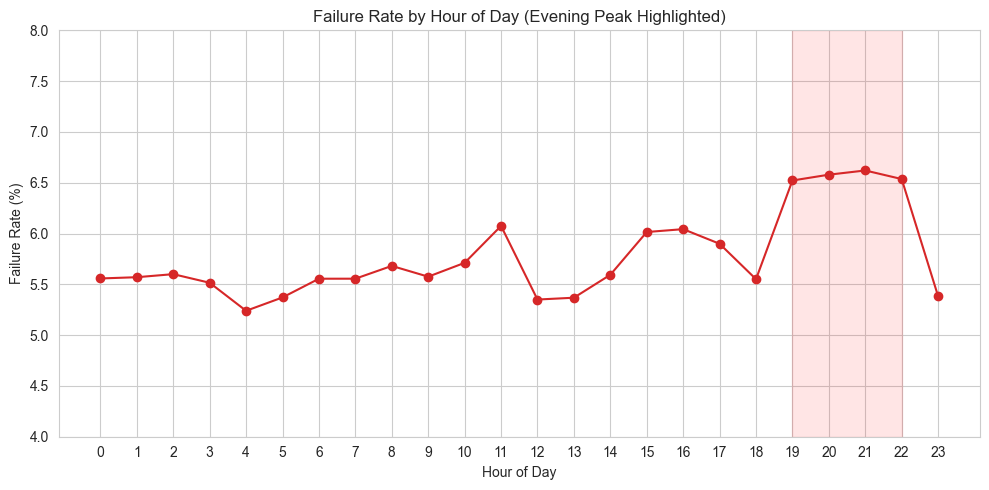

In [104]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(hourly['hour_of_day'], hourly['failure_rate_pct'], color='tab:red', marker='o')
ax.axvspan(19, 22, color='red', alpha=0.1)  # highlight evening peak (x-range only, not full y-axis)
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Failure Rate (%)')
ax.set_ylim(4, 8)  # zoom into the actual data range so the peak is visible
ax.set_title('Failure Rate by Hour of Day (Evening Peak Highlighted)')
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.savefig('../outputs/figures/q2_failure_by_hour.png', dpi=150)
plt.show()

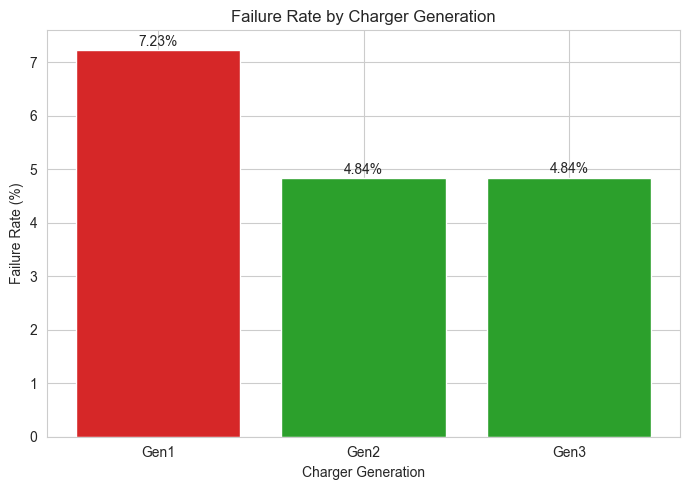

In [103]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(gen_perf['charger_generation'], gen_perf['failure_rate_pct'], color=['#d62728', '#2ca02c', '#2ca02c'])
ax.set_xlabel('Charger Generation')
ax.set_ylabel('Failure Rate (%)')
ax.set_title('Failure Rate by Charger Generation')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q2_failure_by_generation.png', dpi=150)
plt.show()

### Q3: Battery Turnaround Time by Charger Generation

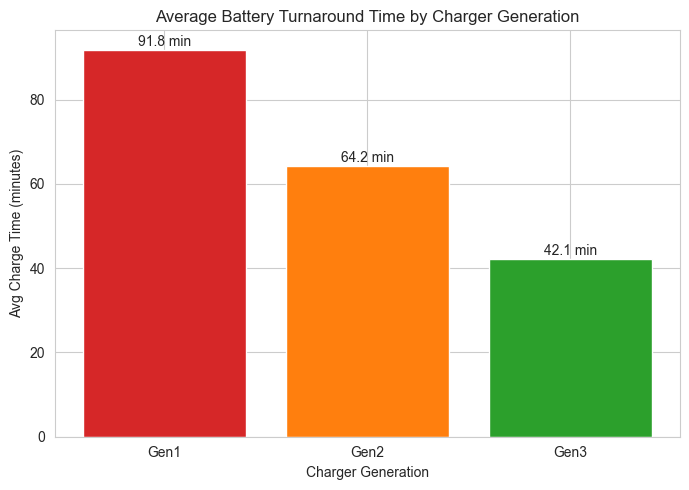

In [106]:
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(gen_turnaround['charger_generation'], gen_turnaround['mean'], color=['#d62728', '#ff7f0e', '#2ca02c'])
ax.set_xlabel('Charger Generation')
ax.set_ylabel('Avg Charge Time (minutes)')
ax.set_title('Average Battery Turnaround Time by Charger Generation')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} min', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q3_turnaround_by_generation.png', dpi=150)
plt.show()

### Q4: Battery Supplier Degradation and Kyron Range Deficit

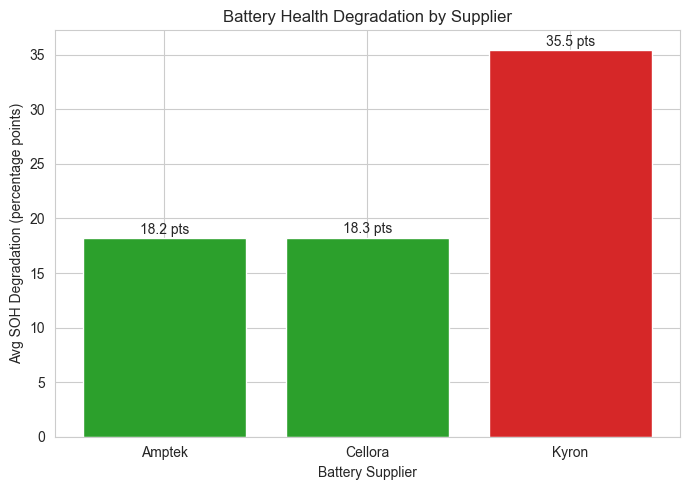

In [108]:
fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ca02c' if s != 'Kyron' else '#d62728' for s in supplier_health['supplier']]
bars = ax.bar(supplier_health['supplier'], supplier_health['avg_degradation'], color=colors)
ax.set_xlabel('Battery Supplier')
ax.set_ylabel('Avg SOH Degradation (percentage points)')
ax.set_title('Battery Health Degradation by Supplier')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} pts', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q4_degradation_by_supplier.png', dpi=150)
plt.show()

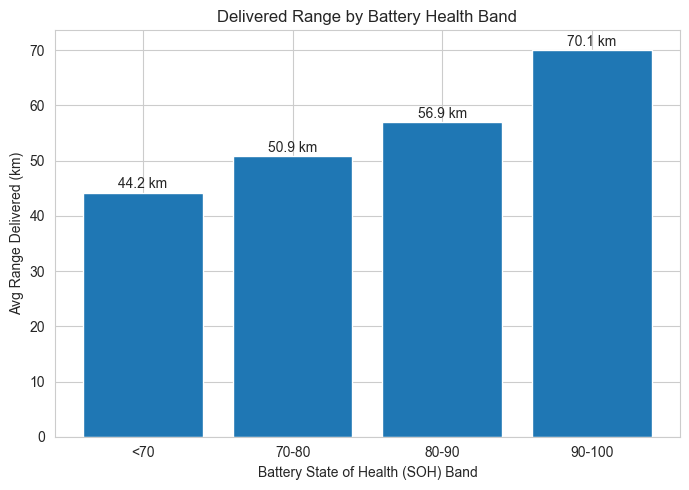

In [109]:
soh_range = completed.groupby('soh_band', observed=True)['km_since_last_swap'].mean().reset_index()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(soh_range['soh_band'].astype(str), soh_range['km_since_last_swap'], color='#1f77b4')
ax.set_xlabel('Battery State of Health (SOH) Band')
ax.set_ylabel('Avg Range Delivered (km)')
ax.set_title('Delivered Range by Battery Health Band')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.1f} km', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q4_range_by_soh_band.png', dpi=150)
plt.show()

### Q5: ZipDrop Margin Impact and Fleet Partner Comparison

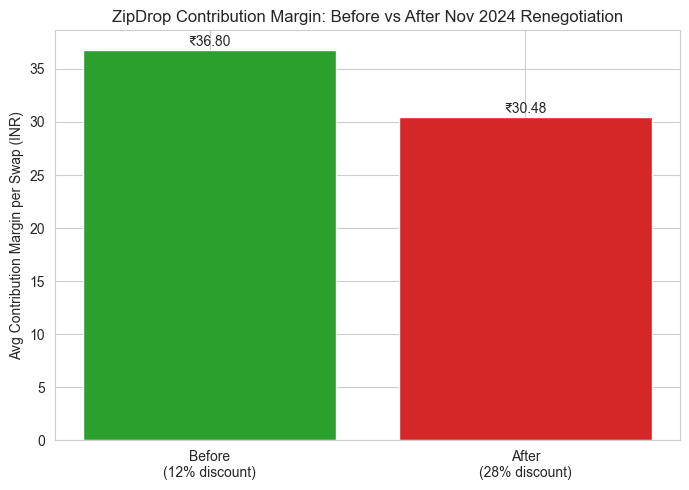

In [111]:
zipdrop_summary = zipdrop_only.groupby('period')['contribution_inr'].mean().reindex(['before_amendment', 'after_amendment'])

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(['Before\n(12% discount)', 'After\n(28% discount)'], zipdrop_summary.values, color=['#2ca02c', '#d62728'])
ax.set_ylabel('Avg Contribution Margin per Swap (INR)')
ax.set_title('ZipDrop Contribution Margin: Before vs After Nov 2024 Renegotiation')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'₹{height:.2f}', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q5_zipdrop_margin_change.png', dpi=150)
plt.show()

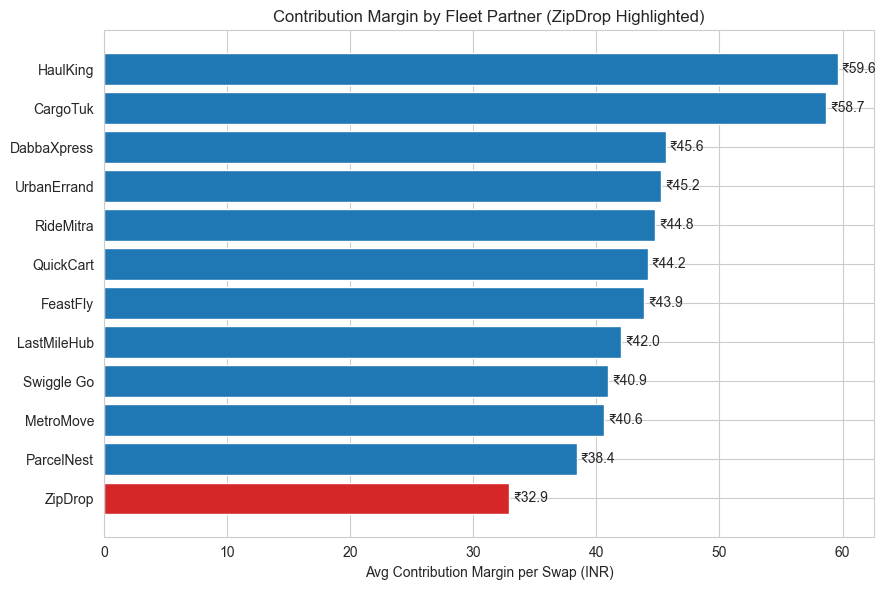

In [112]:
partner_sorted = partner_summary.sort_values('avg_contribution')

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#d62728' if name == 'ZipDrop' else '#1f77b4' for name in partner_sorted['partner_name']]
bars = ax.barh(partner_sorted['partner_name'], partner_sorted['avg_contribution'], color=colors)
ax.set_xlabel('Avg Contribution Margin per Swap (INR)')
ax.set_title('Contribution Margin by Fleet Partner (ZipDrop Highlighted)')
for bar in bars:
    width = bar.get_width()
    ax.annotate(f'₹{width:.1f}', xy=(width, bar.get_y() + bar.get_height()/2),
                xytext=(3, 0), textcoords='offset points', va='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q5_partner_margin_comparison.png', dpi=150)
plt.show()

### Q6: Personal Failure Rate as a Churn Driver

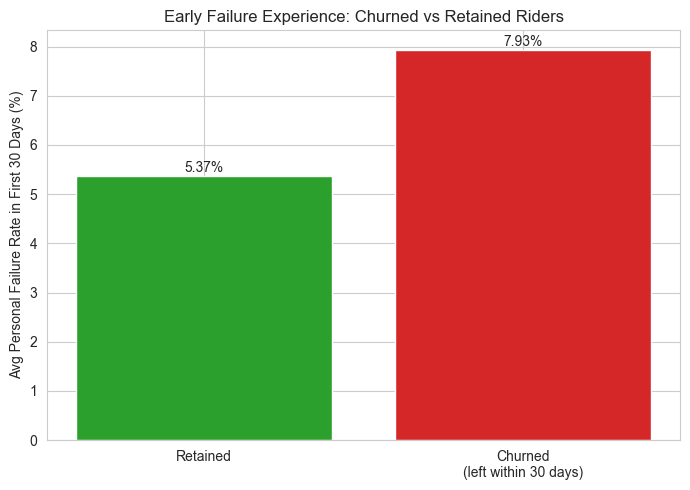

In [114]:
churn_comparison = rider_experience.groupby('churned_early')['personal_failure_rate'].mean().reset_index()
churn_comparison['label'] = churn_comparison['churned_early'].map({True: 'Churned\n(left within 30 days)', False: 'Retained'})

fig, ax = plt.subplots(figsize=(7, 5))
colors = ['#2ca02c', '#d62728']
bars = ax.bar(churn_comparison['label'], churn_comparison['personal_failure_rate'], color=colors)
ax.set_ylabel('Avg Personal Failure Rate in First 30 Days (%)')
ax.set_title('Early Failure Experience: Churned vs Retained Riders')
for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.2f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center')
plt.tight_layout()
plt.savefig('../outputs/figures/q6_churn_failure_rate.png', dpi=150)
plt.show()

## 15. Key Findings Summary

### Summary of Key Findings

**1. Network Performance:** Swaps and revenue grew smoothly throughout the period, masking two distinct underlying issues — a permanent margin increase from a July 2024 price hike, and a recurring seasonal failure spike (10–12%) every April–June driven by extreme heat, which returns unaddressed in both 2024 and 2025.

**2. Service Failures:** Failures are not evenly distributed — they concentrate heavily in Gen1 charger equipment (7.23% vs ~4.84% for Gen2/Gen3) and during evening peak hours (19:00–22:00). Station city/location is a downstream symptom of equipment placement, not an independent cause.

**3. Station & Geographic Patterns:** Charger generation drives turnaround time (91.8 min for Gen1 vs 42.1 min for Gen3) and ticket volume/type. Location type has a modest effect; host type has none.

**4. Battery & Equipment:** Kyron is an underperforming battery supplier across degradation, delivered range, and failure rate. Battery SOH strongly predicts real-world range (not delivered SOC%). 3W's higher failure rate stems from higher per-charge energy demand constraining fleet-wide battery availability — not battery health or station slot capacity.

**5. Pricing & Partner Economics:** The peak/off-peak pilot (Bengaluru, Pune) works as a margin lever with a modest, real shift in rider timing behavior. ZipDrop, the largest fleet partner by volume, delivers the lowest per-swap margin of any partner following a Nov 2024 contract renegotiation (12%→28% discount), costing an estimated ₹21.5 lakh in margin to date.

**6. Retention Root Cause:** New-rider early churn (21.3%) is primarily driven by personal exposure to failed swaps in the first 30 days (7.93% failure rate for churners vs 5.37% for retained riders) — not by city, station generation, fleet affiliation, or signup channel directly. These act as secondary, correlated factors.

### Overall Recommendation Direction
Prioritizing Gen1 charger replacement addresses the two most costly problems simultaneously — network-wide failure rate (Q2/Q3) and new-rider churn (Q6) — while also indirectly reducing Kyron-driven range complaints if paired with a supplier review (Q4). The ZipDrop contract should be revisited given its outsized margin drag (Q5), and the seasonal heat-failure pattern (Q1) warrants a dedicated thermal-management fix ahead of next summer, since it has now repeated identically in two consecutive years.